In [2]:
import os

folder = "../data/raw/"

files = os.listdir(folder)

for file in files:
    print(file)

.gitkeep
extracted_csv
Pass-Fail Data.csv
Titanic Dataset.csv


In [3]:
import pandas as pd

df = pd.read_csv("../data/raw/Pass-Fail Data.csv")

In [4]:
df.shape

(100, 6)

In [5]:
df.columns.tolist()

['student_id',
 'attendance_pct',
 'homework_pct',
 'midterm_score',
 'study_hours_per_week',
 'pass']

In [6]:
df.head()

,student_id,attendance_pct,homework_pct,midterm_score,study_hours_per_week,pass
0,1,95,92,88,12,1
1,2,88,85,79,10,1
2,3,60,55,58,4,0
3,4,72,70,65,6,1
4,5,40,45,50,3,0


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   student_id            100 non-null    int64
 1   attendance_pct        100 non-null    int64
 2   homework_pct          100 non-null    int64
 3   midterm_score         100 non-null    int64
 4   study_hours_per_week  100 non-null    int64
 5   pass                  100 non-null    int64
dtypes: int64(6)
memory usage: 4.8 KB


In [8]:
df.isnull().sum()

student_id              0
attendance_pct          0
homework_pct            0
midterm_score           0
study_hours_per_week    0
pass                    0
dtype: int64

In [9]:
df['pass'].value_counts()

pass
1    60
0    40
Name: count, dtype: int64

In [10]:
df['pass'].value_counts(normalize=True) * 100

pass
1    60.0
0    40.0
Name: proportion, dtype: float64

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df['student_id'].duplicated().sum()

np.int64(0)

In [13]:
df.describe()

,student_id,attendance_pct,homework_pct,midterm_score,study_hours_per_week,pass
count,100.000000,100.000000,100.00000,100.000000,100.00000,100.000000
mean,50.500000,69.520000,69.03000,68.780000,7.28000,0.600000
std,29.011492,17.651783,17.01304,14.717254,3.62115,0.492366
min,1.000000,30.000000,35.00000,42.000000,2.00000,0.000000
25%,25.750000,55.000000,55.00000,56.000000,4.00000,0.000000
50%,50.500000,72.500000,70.00000,68.000000,7.00000,1.000000
75%,75.250000,85.000000,85.00000,82.000000,10.00000,1.000000
max,100.000000,95.000000,96.00000,97.000000,15.00000,1.000000


In [14]:
df.groupby('pass').mean(numeric_only=True)

,student_id,attendance_pct,homework_pct,midterm_score,study_hours_per_week
pass,,,,,
0,51.800000,50.725,51.00,53.725000,3.700000
1,49.633333,82.050,81.05,78.816667,9.666667


In [15]:
df.groupby('pass')[[
    'attendance_pct',
    'homework_pct',
    'midterm_score',
    'study_hours_per_week'
]].agg(['min', 'max', 'mean'])

attendance_pct             homework_pct            midterm_score      \
                min max    mean          min max   mean           min max   
pass                                                                        
0                30  66  50.725           35  63  51.00            42  62   
1                67  95  82.050           65  96  81.05            60  97   

                study_hours_per_week                
           mean                  min max      mean  
pass                                                
0     53.725000                    2   5  3.700000  
1     78.816667                    6  15  9.666667

In [16]:
df.sort_values('attendance_pct')[[
    'attendance_pct',
    'homework_pct',
    'midterm_score',
    'study_hours_per_week',
    'pass'
]].head(20)

,attendance_pct,homework_pct,midterm_score,study_hours_per_week,pass
10,30,35,42,2,0
40,33,38,45,2,0
70,34,39,44,2,0
22,35,40,48,2,0
52,36,41,47,2,0
82,38,42,46,2,0
4,40,45,50,3,0
94,41,43,48,3,0
34,42,44,49,3,0
64,43,45,50,3,0


In [17]:
df.sort_values('attendance_pct')[[
    'attendance_pct',
    'homework_pct',
    'midterm_score',
    'study_hours_per_week',
    'pass'
]].tail(20)

,attendance_pct,homework_pct,midterm_score,study_hours_per_week,pass
87,87,85,83,10,1
65,88,91,93,14,1
18,88,90,86,12,1
1,88,85,79,10,1
78,88,90,87,12,1
54,89,88,86,11,1
95,89,92,94,14,1
38,89,87,83,11,1
8,90,88,84,11,1
24,90,88,85,11,1


In [18]:
def gini_impurity(y):
    total = len(y)

    pass_count = sum(y)
    fail_count = total - pass_count

    p_pass = pass_count / total
    p_fail = fail_count / total

    gini = 1 - (p_pass ** 2 + p_fail ** 2)

    return gini

In [19]:
gini_impurity(df["pass"])

0.48

In [20]:
def weighted_gini(y_left, y_right):
    total = len(y_left) + len(y_right)

    left_weight = len(y_left) / total
    right_weight = len(y_right) / total

    gini_left = gini_impurity(y_left)
    gini_right = gini_impurity(y_right)

    weighted = (
        left_weight * gini_left
        + right_weight * gini_right
    )

    return weighted

In [21]:
left = df[df["attendance_pct"] <= 66]["pass"]
right = df[df["attendance_pct"] > 66]["pass"]

weighted_gini(left, right)

0.0

In [22]:
features = [
    "attendance_pct",
    "homework_pct",
    "midterm_score",
    "study_hours_per_week"
]

In [23]:
def find_best_split(X, y):
    best_gini = float("inf")
    best_feature = None
    best_threshold = None

    for feature in X.columns:

        thresholds = sorted(X[feature].unique())

        for threshold in thresholds:

            left_mask = X[feature] <= threshold
            right_mask = X[feature] > threshold

            y_left = y[left_mask]
            y_right = y[right_mask]

            if len(y_left) == 0 or len(y_right) == 0:
                continue

            gini = weighted_gini(y_left, y_right)

            if gini < best_gini:
                best_gini = gini
                best_feature = feature
                best_threshold = threshold

    return best_feature, best_threshold, best_gini

In [24]:
X = df[
    [
        "attendance_pct",
        "homework_pct",
        "midterm_score",
        "study_hours_per_week"
    ]
]

y = df["pass"]

In [25]:
best_feature, best_threshold, best_gini = find_best_split(X, y)

print("Best feature:", best_feature)
print("Best threshold:", best_threshold)
print("Best Gini:", best_gini)

Best feature: attendance_pct
Best threshold: 66
Best Gini: 0.0


In [26]:
import numpy as np

In [27]:
import numpy as np

# Set a random seed so that we get the same shuffle every time
np.random.seed(42)

# Create an array containing the row positions from 0 to 99
indices = np.arange(len(df))

# Randomly shuffle the row positions
np.random.shuffle(indices)

In [28]:
# Calculate the position where we will split the data
# 80% of the data will be used for training
split_index = int(0.8 * len(df))

# Select the first 80% of the shuffled indices for training
train_indices = indices[:split_index]

# Select the remaining 20% of the shuffled indices for testing
test_indices = indices[split_index:]

In [29]:
# Create X_train, X_test, y_train and y_test
X_train = X.iloc[train_indices]
X_test = X.iloc[test_indices]

y_train = y.iloc[train_indices]
y_test = y.iloc[test_indices]

In [30]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (80, 4)
X_test: (20, 4)
y_train: (80,)
y_test: (20,)


In [31]:
# find the best split using only training data
best_feature, best_threshold, best_gini = find_best_split(
    X_train,
    y_train
)

print("Best feature:", best_feature)
print("Best threshold:", best_threshold)
print("Best Gini:", best_gini)

Best feature: attendance_pct
Best threshold: 66
Best Gini: 0.0


In [32]:
class Node:
    def __init__(
        self,
        feature=None,
        threshold=None,
        left=None,
        right=None,
        value=None
    ):
        # Feature used to split the data
        self.feature = feature

        # Threshold used for the split
        self.threshold = threshold

        # Left child node
        self.left = left

        # Right child node
        self.right = right

        # Prediction stored in a leaf node
        self.value = value

In [33]:
def majority_class(y):
    # Count the number of Pass and Fail students
    pass_count = sum(y)
    fail_count = len(y) - pass_count

    # Return Pass if Pass is the majority
    if pass_count >= fail_count:
        return 1

    # Otherwise return Fail
    return 0

In [34]:
majority_class([1, 1, 1, 0, 0])

1

In [35]:
def build_tree(X, y, depth=0, max_depth=5):
    
    # Stop if the group is empty
    if len(y) == 0:
        return None

    # Stop if all students belong to the same class
    if len(set(y)) == 1:
        return Node(value=y.iloc[0])

    # Stop if we have reached the maximum tree depth
    if depth >= max_depth:
        return Node(value=majority_class(y))

    # Find the best feature and threshold for this group
    best_feature, best_threshold, best_gini = find_best_split(X, y)

    # Stop if no useful split was found
    if best_feature is None:
        return Node(value=majority_class(y))

    # Divide the data using the best split
    left_mask = X[best_feature] <= best_threshold
    right_mask = X[best_feature] > best_threshold

    # Create the left and right datasets
    X_left = X[left_mask]
    X_right = X[right_mask]

    # Create the left and right target groups
    y_left = y[left_mask]
    y_right = y[right_mask]

    # Recursively build the left side of the tree
    left_node = build_tree(
        X_left,
        y_left,
        depth + 1,
        max_depth
    )

    # Recursively build the right side of the tree
    right_node = build_tree(
        X_right,
        y_right,
        depth + 1,
        max_depth
    )

    # Return a decision node containing the split and child nodes
    return Node(
        feature=best_feature,
        threshold=best_threshold,
        left=left_node,
        right=right_node
    )

In [36]:
# Build the Decision Tree using only the training data
tree = build_tree(
    X_train,
    y_train,
    max_depth=5
)

In [37]:
# Check the type of object created by the tree-building function
print(type(tree))

<class '__main__.Node'>


In [38]:
def print_tree(node, depth=0):
    # Stop if there is no node
    if node is None:
        return

    # Create indentation based on the depth of the tree
    indent = "    " * depth

    # If the node is a leaf, display its prediction
    if node.value is not None:
        class_name = "Pass" if node.value == 1 else "Fail"
        print(f"{indent}Leaf: {class_name}")
        return

    # Display the decision rule at this node
    print(f"{indent}{node.feature} <= {node.threshold}")

    # Display the branch where the condition is True
    print(f"{indent}├── True:")
    print_tree(node.left, depth + 1)

    # Display the branch where the condition is False
    print(f"{indent}└── False:")
    print_tree(node.right, depth + 1)

In [39]:
# Display the structure learned by the Decision Tree
print_tree(tree)

attendance_pct <= 66
├── True:
    Leaf: Fail
└── False:
    Leaf: Pass


In [40]:
def predict_one(node, row):
    # If we reach a leaf node, return the prediction stored in that leaf
    if node.value is not None:
        return node.value

    # Follow the left branch if the student's value is
    # less than or equal to the threshold
    if row[node.feature] <= node.threshold:
        return predict_one(node.left, row)

    # Otherwise, follow the right branch
    return predict_one(node.right, row)

In [41]:
def predict(tree, X):
    # Create an empty list to store the predictions
    predictions = []

    # Go through each student in the dataset
    for _, row in X.iterrows():

        # Predict whether the student will Pass or Fail
        prediction = predict_one(tree, row)

        # Add the prediction to the list
        predictions.append(prediction)

    # Convert the predictions into a NumPy array
    return np.array(predictions)

In [42]:
# Use the trained Decision Tree to predict the test data
y_pred = predict(tree, X_test)

# Display the predictions
print(y_pred)

[1 1 0 0 1 0 1 0 1 1 1 1 0 0 0 1 1 1 0 1]


In [43]:
# Display the actual results and the model's predictions side by side
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

# Display the comparison
print(comparison)

    Actual  Predicted
0        1          1
1        1          1
2        0          0
3        0          0
4        1          1
5        0          0
6        1          1
7        0          0
8        1          1
9        1          1
10       1          1
11       1          1
12       0          0
13       0          0
14       0          0
15       1          1
16       1          1
17       1          1
18       0          0
19       1          1


In [44]:
# Compare the actual values with the predicted values
correct_predictions = sum(y_test.values == y_pred)

# Display the number of correct predictions
print("Correct predictions:", correct_predictions)

# Display the total number of test students
print("Total test students:", len(y_test))

Correct predictions: 20
Total test students: 20


In [45]:
# Count how many predictions match the actual results
correct_predictions = sum(y_test.values == y_pred)

# Calculate the total number of test observations
total_predictions = len(y_test)

# Calculate accuracy as the proportion of correct predictions
accuracy = correct_predictions / total_predictions

# Convert accuracy to a percentage
accuracy_percentage = accuracy * 100

# Display the results
print("Correct predictions:", correct_predictions)
print("Total predictions:", total_predictions)
print("Accuracy:", accuracy_percentage, "%")

Correct predictions: 20
Total predictions: 20
Accuracy: 100.0 %


In [46]:
# Count True Positives, True Negatives, False Positives, and False Negatives
TP = 0
TN = 0
FP = 0
FN = 0

# Compare each actual value with its predicted value
for actual, predicted in zip(y_test, y_pred):

    # Actual Pass and predicted Pass
    if actual == 1 and predicted == 1:
        TP += 1

    # Actual Fail and predicted Fail
    elif actual == 0 and predicted == 0:
        TN += 1

    # Actual Fail but predicted Pass
    elif actual == 0 and predicted == 1:
        FP += 1

    # Actual Pass but predicted Fail
    elif actual == 1 and predicted == 0:
        FN += 1

# Display the results
print("True Positives:", TP)
print("True Negatives:", TN)
print("False Positives:", FP)
print("False Negatives:", FN)

True Positives: 12
True Negatives: 8
False Positives: 0
False Negatives: 0


In [47]:
# Calculate precision
# Precision measures how many predicted Pass students actually passed
precision = TP / (TP + FP)

# Display precision as a percentage
print("Precision:", precision * 100, "%")

Precision: 100.0 %


In [48]:
# Calculate recall
# Recall measures how many actual Pass students were correctly identified
recall = TP / (TP + FN)

# Display recall as a percentage
print("Recall:", recall * 100, "%")

Recall: 100.0 %


In [49]:
# Calculate the F1 score using precision and recall
f1_score = 2 * (precision * recall) / (precision + recall)

# Display the F1 score as a percentage
print("F1 Score:", f1_score * 100, "%")

F1 Score: 100.0 %


In [50]:
# Store the different maximum depths we want to test
depths = [1, 2, 3, 4, 5]

# Store the accuracy for each tree
depth_accuracies = []

# Test each maximum depth
for depth in depths:

    # Build a new Decision Tree using the selected maximum depth
    test_tree = build_tree(
        X_train,
        y_train,
        max_depth=depth
    )

    # Use the tree to make predictions on the test data
    test_predictions = predict(
        test_tree,
        X_test
    )

    # Count the number of correct predictions
    correct = sum(y_test.values == test_predictions)

    # Calculate the accuracy
    accuracy = correct / len(y_test)

    # Store the accuracy
    depth_accuracies.append(accuracy)

# Display the results
for depth, accuracy in zip(depths, depth_accuracies):
    print(
        f"Max depth {depth}: "
        f"{accuracy * 100:.1f}% accuracy"
    )

Max depth 1: 100.0% accuracy
Max depth 2: 100.0% accuracy
Max depth 3: 100.0% accuracy
Max depth 4: 100.0% accuracy
Max depth 5: 100.0% accuracy


In [51]:
# Build the final Decision Tree using the simplest effective depth
final_tree = build_tree(
    X_train,
    y_train,
    max_depth=1
)

# Display the final tree structure
print_tree(final_tree)

attendance_pct <= 66
├── True:
    Leaf: Fail
└── False:
    Leaf: Pass


In [52]:
# Select the first student from the test dataset
student = X_test.iloc[0]

# Display the student's feature values
print(student)

attendance_pct          74
homework_pct            72
midterm_score           69
study_hours_per_week     7
Name: 63, dtype: int64


In [53]:
# Use our Decision Tree to predict this student's result
prediction = predict_one(final_tree, student)

# Convert the numeric prediction into a readable label
result = "Pass" if prediction == 1 else "Fail"

# Display the prediction
print("Predicted result:", result)

Predicted result: Pass


In [54]:
# Get the actual result of the selected test student
actual = y_test.iloc[0]

# Convert the numeric actual value into a readable label
actual_result = "Pass" if actual == 1 else "Fail"

# Display both the actual result and the model prediction
print("Actual result:", actual_result)
print("Predicted result:", result)

Actual result: Pass
Predicted result: Pass


In [55]:
# Calculate the main evaluation metrics for the final Decision Tree

# Accuracy measures the overall percentage of correct predictions
accuracy = (TP + TN) / (TP + TN + FP + FN)

# Precision measures how many predicted Pass students actually passed
precision = TP / (TP + FP)

# Recall measures how many actual Pass students were correctly identified
recall = TP / (TP + FN)

# F1 combines precision and recall into one score
f1 = 2 * (precision * recall) / (precision + recall)

# Display the final evaluation results
print("Final Decision Tree Evaluation")
print("--------------------------------")
print(f"Accuracy:  {accuracy * 100:.1f}%")
print(f"Precision: {precision * 100:.1f}%")
print(f"Recall:    {recall * 100:.1f}%")
print(f"F1 Score:  {f1 * 100:.1f}%")

Final Decision Tree Evaluation
--------------------------------
Accuracy:  100.0%
Precision: 100.0%
Recall:    100.0%
F1 Score:  100.0%


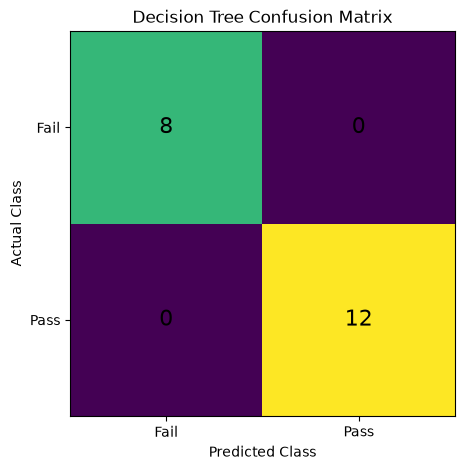

In [56]:
import matplotlib.pyplot as plt

# Create the confusion matrix using our calculated values
confusion_matrix = [
    [TN, FP],
    [FN, TP]
]

# Create the figure
plt.figure(figsize=(7, 5))

# Display the confusion matrix as an image
plt.imshow(confusion_matrix)

# Add the values inside each cell
for row in range(2):
    for column in range(2):
        plt.text(
            column,
            row,
            confusion_matrix[row][column],
            ha="center",
            va="center",
            fontsize=16
        )

# Add the class labels
plt.xticks(
    [0, 1],
    ["Fail", "Pass"]
)

plt.yticks(
    [0, 1],
    ["Fail", "Pass"]
)

# Add axis labels
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

# Add a title
plt.title("Decision Tree Confusion Matrix")

# Display the visualization
plt.show()

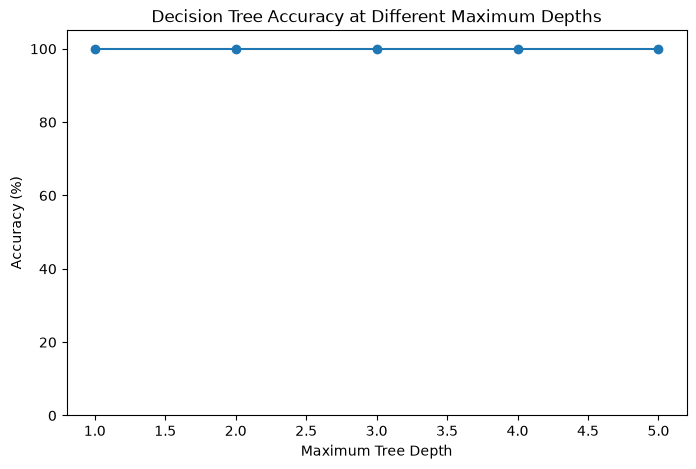

In [57]:
import matplotlib.pyplot as plt

# Create a line chart showing accuracy for each tree depth
plt.figure(figsize=(8, 5))

# Plot the accuracy for each maximum depth
plt.plot(
    depths,
    [accuracy * 100 for accuracy in depth_accuracies],
    marker="o"
)

# Add labels and a title
plt.xlabel("Maximum Tree Depth")
plt.ylabel("Accuracy (%)")
plt.title("Decision Tree Accuracy at Different Maximum Depths")

# Make the y-axis easier to interpret
plt.ylim(0, 105)

# Display the chart
plt.show()

# Student Pass/Fail Classification Using a Decision Tree

## 1. Introduction

This project focuses on building a machine learning classification model that predicts whether a student will **Pass or Fail** based on academic and study-related information.

The main objective was to understand and implement the working principles of a **Decision Tree classifier from scratch**, without relying on machine learning libraries such as scikit-learn.

The project uses student information such as attendance percentage, homework percentage, midterm score, and study hours per week to predict the student's final class.

---

## 2. Dataset

The dataset used in this project is the **Student Pass/Fail Data** dataset obtained from Kaggle.

The dataset contains **100 student records and 6 columns**:

| Column                 | Description                         |
| ---------------------- | ----------------------------------- |
| `student_id`           | Unique identifier for each student  |
| `attendance_pct`       | Student attendance percentage       |
| `homework_pct`         | Homework performance percentage     |
| `midterm_score`        | Midterm examination score           |
| `study_hours_per_week` | Average study hours per week        |
| `pass`                 | Target variable: 1 = Pass, 0 = Fail |

The `student_id` column was not used as a prediction feature because it is only an identifier and does not contain meaningful information about student performance.

### Dataset Source

**Kaggle – Student Pass/Fail Data**

https://www.kaggle.com/datasets/ishanjha100/student-passfail-data

The dataset source should be documented in both this report and the project README so that the origin of the data is clear and reproducible.

---

## 3. Data Inspection and Preparation

Before building the model, the dataset was inspected to understand its structure and quality.

The dataset contained:

* 100 rows
* 6 columns
* No missing values
* No duplicate records
* All variables were stored as numerical values
* 60 students were classified as Pass
* 40 students were classified as Fail

The target variable was `pass`, where:

* `1` represents Pass
* `0` represents Fail

The four predictor variables used were:

```text
attendance_pct
homework_pct
midterm_score
study_hours_per_week
```

---

## 4. Exploratory Analysis

The data was explored to understand the relationship between the input variables and the target class.

The analysis showed that students who passed generally had higher attendance, homework scores, midterm scores, and study hours than students who failed.

The class averages were approximately:

| Feature          |  Fail |  Pass |
| ---------------- | ----: | ----: |
| Attendance       | 50.73 | 82.05 |
| Homework         | 51.00 | 81.05 |
| Midterm          | 53.73 | 78.82 |
| Study hours/week |  3.70 |  9.67 |

Attendance showed particularly strong separation between the two classes.

---

## 5. Train/Test Split

The dataset was divided into two parts:

* **80% training data** – used to build the Decision Tree
* **20% testing data** – used to evaluate the model

Because the assignment required implementing the algorithm without scikit-learn, the train/test split was also implemented manually using NumPy.

A random seed of 42 was used so that the same split could be reproduced.

The final split consisted of:

* 80 training students
* 20 testing students

---

## 6. Decision Tree Algorithm

A Decision Tree works by repeatedly asking questions about the data and dividing it into groups.

For this project, the tree was implemented from scratch.

The main stages were:

1. Calculate Gini impurity.
2. Calculate the weighted Gini impurity for possible splits.
3. Search for the best feature and threshold.
4. Create tree nodes.
5. Recursively build the tree.
6. Use the tree to make predictions.

---

## 7. Gini Impurity

Gini impurity was used to measure how mixed the Pass and Fail classes are within a group.

The formula used was:

**Gini = 1 − (P(Pass)² + P(Fail)²)**

A Gini value of:

* `0` means the group is completely pure.
* A higher value means the classes are more mixed.

For the original dataset, there were 60 Pass students and 40 Fail students, giving a root Gini impurity of approximately **0.48**.

The Decision Tree searches for splits that reduce this impurity.

---

## 8. Weighted Gini Impurity

After dividing the data into a left and right group, the weighted Gini impurity was calculated.

This takes into account both:

* The impurity of each group
* The number of observations in each group

The tree then compares different possible splits and selects the split with the lowest weighted Gini impurity.

---

## 9. Finding the Best Split

The algorithm tested different features and thresholds.

For each possible split, the data was divided into:

```text
Left group:  feature <= threshold
Right group: feature > threshold
```

The weighted Gini impurity was then calculated.

The best split found by the algorithm was:

```text
attendance_pct <= 66
```

This split produced a completely pure separation for the training data.

---

## 10. Building the Decision Tree

A `Node` class was created to represent the different parts of the Decision Tree.

Each node can contain:

* The feature used for splitting
* The threshold
* A left child
* A right child
* A prediction value for a leaf

The tree was built recursively.

The algorithm stops creating new branches when:

* All observations belong to the same class.
* The maximum tree depth is reached.
* No useful split can be found.

---

## 11. Final Decision Tree

The final effective tree was:

```text
attendance_pct <= 66
├── True
│   └── Fail
│
└── False
    └── Pass
```

This means:

```text
If attendance <= 66% → Fail

If attendance > 66% → Pass
```

The tree has a maximum depth of **1**.

This makes the model very simple and easy to interpret.

---

## 12. Making Predictions

A prediction function was implemented from scratch.

For every new student, the algorithm starts at the root of the tree and follows the appropriate branch.

For example, one test student had:

```text
Attendance = 74%
Homework = 72%
Midterm = 69%
Study hours = 7
```

The tree checks:

```text
74 <= 66?
```

The answer is **No**, so the student follows the right branch.

The prediction is therefore:

```text
Pass
```

---

## 13. Model Evaluation

The model was evaluated using the 20 students in the test set.

The results were:

| Metric    | Result |
| --------- | -----: |
| Accuracy  |   100% |
| Precision |   100% |
| Recall    |   100% |
| F1 Score  |   100% |

The model correctly classified all 20 test students.

---

## 14. Confusion Matrix

The confusion matrix was calculated manually.

| Actual / Predicted | Fail | Pass |
| ------------------ | ---: | ---: |
| **Fail**           |    8 |    0 |
| **Pass**           |    0 |   12 |

The results are:

* **True Negatives (TN) = 8**
* **True Positives (TP) = 12**
* **False Positives (FP) = 0**
* **False Negatives (FN) = 0**

Therefore, all 20 test students were classified correctly.

---

## 15. Testing Different Tree Depths

To determine an appropriate tree complexity, different maximum depths were tested.

| Maximum Depth | Accuracy |
| ------------: | -------: |
|             1 |     100% |
|             2 |     100% |
|             3 |     100% |
|             4 |     100% |
|             5 |     100% |

Since increasing the depth did not improve the accuracy, a maximum depth of **1** was selected.

This provides the simplest model while maintaining the same performance.

---

## 16. Important Limitation

Although the model achieved 100% accuracy, this result should be interpreted carefully.

Exploratory analysis showed unusually strong separation between the Pass and Fail classes. In particular, attendance alone was enough for the Decision Tree to perfectly separate the two classes.

This suggests that the dataset may represent a simplified or rule-based classification problem.

Therefore, the 100% accuracy achieved on this test set should **not** be interpreted as proof that the model would achieve 100% accuracy on students from a different or real-world dataset.

External validation using a more realistic student-performance dataset would be useful for determining how well the model generalizes.

---

## 17. Conclusion

This project successfully demonstrated the implementation of a Decision Tree classifier from scratch without using scikit-learn.

The main stages completed were:

1. Loading and inspecting the dataset.
2. Checking data quality.
3. Selecting appropriate features and the target.
4. Splitting the data into training and testing sets.
5. Implementing Gini impurity.
6. Implementing weighted Gini impurity.
7. Finding the best feature and threshold.
8. Building the Decision Tree recursively.
9. Implementing prediction.
10. Evaluating the model.
11. Creating a confusion matrix.
12. Testing different tree depths.
13. Visualizing model performance.

The final Decision Tree used attendance percentage as its main decision rule and achieved 100% accuracy on the 20-student test set.

However, because the dataset showed unusually strong class separation, further testing on an external real-world dataset would be necessary before using the model for practical student-performance prediction.

---

## 18. Dataset Citation / Source

The dataset should be cited in the project documentation as follows:

**Ishan Jha. Student Pass/Fail Data. Kaggle.**

Dataset URL:

https://www.kaggle.com/datasets/ishanjha100/student-passfail-data



